In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check for GPU availability
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Number of GPUs: {len(tf.config.list_physical_devices('GPU'))}")


Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.9.2
GPU Available: []
Number of GPUs: 0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 300s 2us/step
Dataset loaded successfully!
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10
Pixel value range: 0 to 255


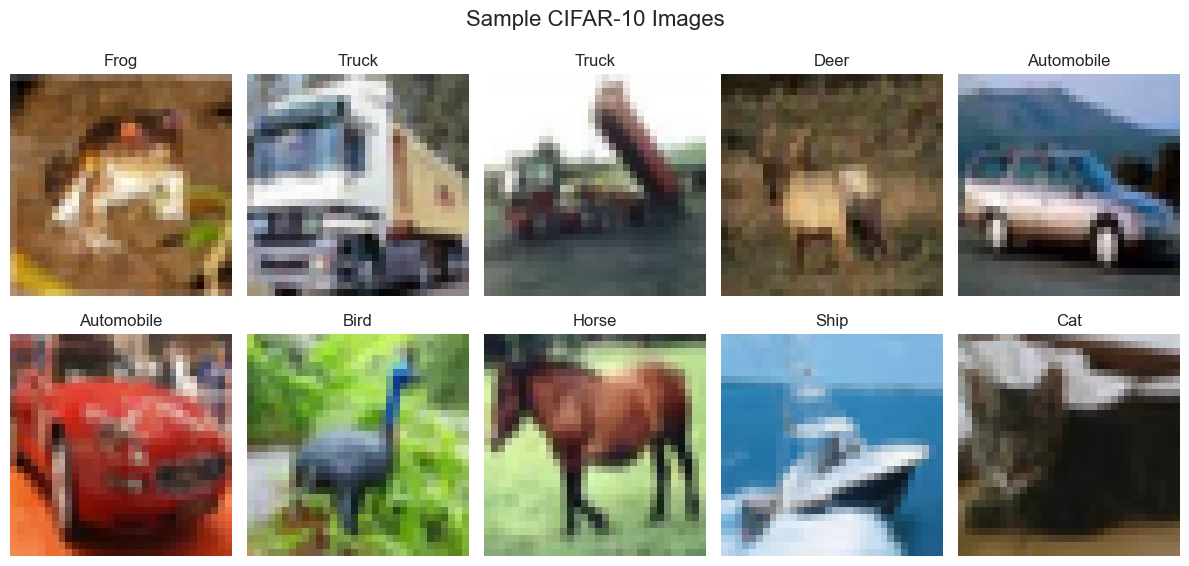


After preprocessing:
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Pixel value range: 0.0 to 1.0
Label format: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [2]:
# Load and preprocess CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Class names for CIFAR-10
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Dataset loaded successfully!")
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Number of classes: {len(class_names)}")
print(f"Pixel value range: {x_train.min()} to {x_train.max()}")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample CIFAR-10 Images', fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(x_train[i])
    axes[row, col].set_title(f'{class_names[y_train[i][0]]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Data preprocessing
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
y_train_categorical = keras.utils.to_categorical(y_train, 10)
y_test_categorical = keras.utils.to_categorical(y_test, 10)

print(f"\nAfter preprocessing:")
print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train_categorical.shape}")
print(f"Pixel value range: {x_train.min()} to {x_train.max()}")
print(f"Label format: {y_train_categorical[0]}")  # One-hot encoded


In [6]:
# Build CNN Architecture
def create_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    """
    Create a CNN model for CIFAR-10 classification
    
    Args:
        input_shape: Shape of input images
        num_classes: Number of output classes
    
    Returns:
        model: Compiled Keras model
    """
    model = keras.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Fully Connected Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
model = create_cnn_model()

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
print("Model Architecture:")
model.summary()

# Plot model architecture
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

# Calculate total parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")


Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,344,170 (5.13 MB)

 Trainable params: 1,342,698 (5.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

You must install pydot (`pip install pydot`) for `plot_model` to work.

Total parameters: 1,344,170


Starting model training...
Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.3821 - loss: 1.8505

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 397s 245ms/step - accuracy: 0.3822 - loss: 1.8503 - val_accuracy: 0.5549 - val_loss: 1.2858 - learning_rate: 0.0010
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6330 - loss: 1.0454

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 378s 204ms/step - accuracy: 0.6330 - loss: 1.0454 - val_accuracy: 0.6405 - val_loss: 1.0607 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.6967 - loss: 0.8730

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 291s 186ms/step - accuracy: 0.6967 - loss: 0.8730 - val_accuracy: 0.7424 - val_loss: 0.7642 - learning_rate: 0.0010
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 245s 157ms/step - accuracy: 0.7304 - loss: 0.7709 - val_accuracy: 0.6911 - val_loss: 0.9443 - learning_rate: 0.0010
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.7608 - loss: 0.6933

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 252s 161ms/step - accuracy: 0.7608 - loss: 0.6933 - val_accuracy: 0.7592 - val_loss: 0.7214 - learning_rate: 0.0010
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7848 - loss: 0.6261

...

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 706s 452ms/step - accuracy: 0.8134 - loss: 0.5415 - val_accuracy: 0.8107 - val_loss: 0.5624 - learning_rate: 0.0010
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 549s 351ms/step - accuracy: 0.8214 - loss: 0.5063 - val_accuracy: 0.7850 - val_loss: 0.6800 - learning_rate: 0.0010
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.8358 - loss: 0.4782

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 315s 202ms/step - accuracy: 0.8358 - loss: 0.4782 - val_accuracy: 0.8188 - val_loss: 0.5566 - learning_rate: 0.0010
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 270s 173ms/step - accuracy: 0.8458 - loss: 0.4488 - val_accuracy: 0.8177 - val_loss: 0.5672 - learning_rate: 0.0010
Epoch 12/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 296s 189ms/step - accuracy: 0.8496 - loss: 0.4267 - val_accuracy: 0.8025 - val_loss: 0.6142 - learning_rate: 0.0010
Epoch 13/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8585 - loss: 0.4087

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 297s 173ms/step - accuracy: 0.8585 - loss: 0.4087 - val_accuracy: 0.8338 - val_loss: 0.5207 - learning_rate: 0.0010
Epoch 14/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8652 - loss: 0.3845

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 303s 194ms/step - accuracy: 0.8652 - loss: 0.3845 - val_accuracy: 0.8371 - val_loss: 0.5056 - learning_rate: 0.0010
Epoch 15/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 302s 193ms/step - accuracy: 0.8692 - loss: 0.3688 - val_accuracy: 0.8305 - val_loss: 0.5555 - learning_rate: 0.0010
Epoch 16/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 242s 155ms/step - accuracy: 0.8755 - loss: 0.3579 - val_accuracy: 0.8374 - val_loss: 0.5079 - learning_rate: 0.0010
Epoch 17/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 241s 154ms/step - accuracy: 0.8807 - loss: 0.3349 - val_accuracy: 0.8344 - val_loss: 0.5311 - learning_rate: 0.0010
Epoch 18/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.8980 - loss: 0.2877

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 241s 154ms/step - accuracy: 0.8980 - loss: 0.2876 - val_accuracy: 0.8544 - val_loss: 0.4624 - learning_rate: 2.0000e-04
Epoch 19/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 261s 154ms/step - accuracy: 0.9100 - loss: 0.2554 - val_accuracy: 0.8546 - val_loss: 0.4761 - learning_rate: 2.0000e-04
Epoch 20/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 292s 187ms/step - accuracy: 0.9155 - loss: 0.2366 - val_accuracy: 0.8606 - val_loss: 0.4697 - learning_rate: 2.0000e-04
Epoch 21/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 456s 292ms/step - accuracy: 0.9215 - loss: 0.2216 - val_accuracy: 0.8592 - val_loss: 0.4754 - learning_rate: 2.0000e-04
Epoch 22/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 392s 221ms/step - accuracy: 0.9227 - loss: 0.2162 - val_accuracy: 0.8605 - val_loss: 0.4700 - learning_rate: 4.0000e-05
Epoch 23/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 194s 124ms/step - accuracy: 0.9309 - loss: 0.1992 - val_accuracy: 0.8611 - val_loss: 0.4691 - learning_rate: 4.0000e-05
Training completed!
Test Accuracy:

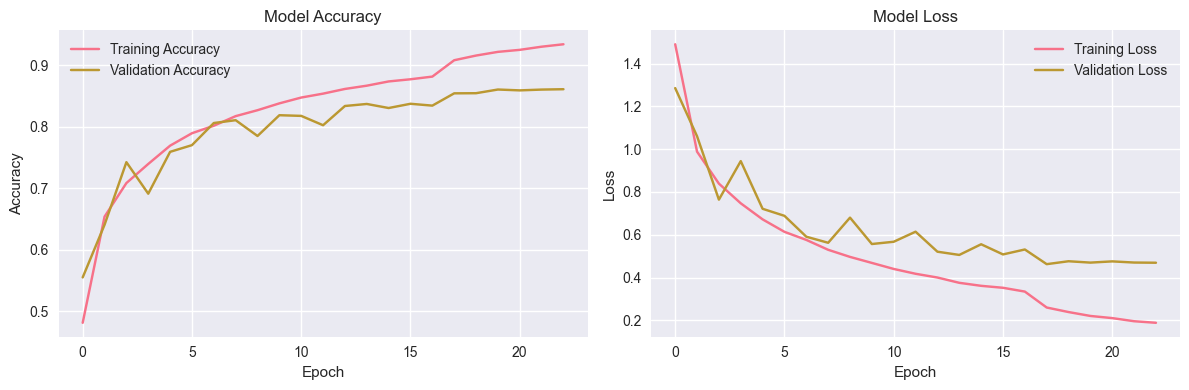

In [7]:
# Train the model
print("Starting model training...")

# Define callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
    keras.callbacks.ModelCheckpoint('best_cifar10_cnn.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    x_train, y_train_categorical,
    batch_size=32,
    epochs=50,
    validation_data=(x_test, y_test_categorical),
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

# Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)
